In [ ]:
!pip install -U ultralytics

!pip install -U gdown

!pip install -U PyYAML

!pip install -U pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 21.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 102.4 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.3.3
    Uninstalling pandas-2.3.3:
      Successfully uninstalled pandas-2.3.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
ydata-profil

In [2]:
import os
import shutil
import random
import yaml
import gdown
from pathlib import Path
from collections import defaultdict

# 1. Download dari Google Drive
datasets = {
    'WIDERFace.zip': '1hs7fvHb8-TZHFj_DHCuEZZDguulgqx7Z',
    'CocoPerson.zip': '1w6tlslcIPiSAwgUgd98G80oueINnTd57'
}

for filename, file_id in datasets.items():
    if not os.path.exists(filename):
        url = f'https://drive.google.com/uc?id={file_id}'
        gdown.download(url, filename, quiet=False)

# 2. Extract Data
if not os.path.exists('WIDER-FACE-1'):
    !unzip -q WIDERFace.zip -d WIDER-FACE-1
if not os.path.exists('COCO-PERSON-1'):
    !unzip -q CocoPerson.zip -d COCO-PERSON-1

def fix_mixed_split_kaggle(output_path, split_ratio=(0.8, 0.1, 0.1)):
    # Setup folder tujuan
    for split in ['train', 'val', 'test']:
        os.makedirs(os.path.join(output_path, split, 'images'), exist_ok=True)
        os.makedirs(os.path.join(output_path, split, 'labels'), exist_ok=True)

    # Dictionary untuk menampung data sementara
    # format: {'train': [(path_img, path_lbl, is_person), ...]}
    final_splits = {'train': [], 'val': [], 'test': []}
    random.seed(42)

    # --- PROSES WIDERFACE (Class 0: Face) ---
    wider_map = defaultdict(list)
    for folder in ['train', 'valid', 'test']:
        img_dir = Path('WIDER-FACE-1') / folder / 'images'
        if not img_dir.exists(): continue
        for img_path in img_dir.glob('*.jpg'):
            label_path = Path('WIDER-FACE-1') / folder / 'labels' / (img_path.stem + '.txt')
            if label_path.exists():
                category = "_".join(img_path.stem.split('_')[:2])
                wider_map[category].append((img_path, label_path, False)) # False = Bukan person

    for cat, pairs in wider_map.items():
        random.shuffle(pairs)
        n = len(pairs)
        tr_end = int(n * split_ratio[0])
        val_end = tr_end + int(n * split_ratio[1])
        final_splits['train'].extend(pairs[:tr_end])
        final_splits['val'].extend(pairs[tr_end:val_end])
        final_splits['test'].extend(pairs[val_end:])

    # --- PROSES COCOPERSON (Class 1: Person) ---
    person_pairs = []
    for folder in ['train', 'valid', 'test']:
        img_dir = Path('COCO-PERSON-1') / folder / 'images'
        if not img_dir.exists(): continue
        for img_path in img_dir.glob('*.jpg'):
            label_path = Path('COCO-PERSON-1') / folder / 'labels' / (img_path.stem + '.txt')
            if label_path.exists():
                person_pairs.append((img_path, label_path, True)) # True = Person
    
    random.shuffle(person_pairs)
    n_p = len(person_pairs)
    p_tr_end = int(n_p * split_ratio[0])
    p_val_end = p_tr_end + int(n_p * split_ratio[1])
    
    final_splits['train'].extend(person_pairs[:p_tr_end])
    final_splits['val'].extend(person_pairs[p_tr_end:p_val_end])
    final_splits['test'].extend(person_pairs[p_val_end:])

    # --- COPY & REMAP LABELS ---
    for name, pairs in final_splits.items():
        print(f"Processing {name} split: {len(pairs)} files...")
        for img, lbl, is_person in pairs:
            target_img = os.path.join(output_path, name, 'images', img.name)
            target_lbl = os.path.join(output_path, name, 'labels', lbl.name)
            
            # Copy Gambar
            shutil.copy2(img, target_img)
            
            if is_person:
                # REMAP: Baca isi label, ganti class ID dari 0 (atau apapun) ke 1
                with open(lbl, 'r') as f:
                    lines = f.readlines()
                
                new_lines = []
                for line in lines:
                    parts = line.split()
                    if len(parts) > 0:
                        parts[0] = '1' # Set class ke 1 (person)
                        new_lines.append(" ".join(parts))
                
                with open(target_lbl, 'w') as f:
                    f.write("\n".join(new_lines))
            else:
                # Untuk Face, pastikan class ID adalah 0 (WIDERFace biasanya sudah 0)
                # Jika ragu, bisa diremap paksa ke '0' juga di sini
                shutil.copy2(lbl, target_lbl)

    # 3. Buat data.yaml baru
    data_yaml = {
        'train': os.path.abspath(os.path.join(output_path, 'train', 'images')),
        'val': os.path.abspath(os.path.join(output_path, 'val', 'images')),
        'test': os.path.abspath(os.path.join(output_path, 'test', 'images')),
        'nc': 2,
        'names': ['face', 'person']
    }
    with open(os.path.join(output_path, 'data.yaml'), 'w') as f:
        yaml.dump(data_yaml, f)

# Eksekusi
fix_mixed_split_kaggle('Face_Person')
print("Done! Dataset mixed sudah siap dengan remap class person ke ID 1.")

Downloading...
From (original): https://drive.google.com/uc?id=1hs7fvHb8-TZHFj_DHCuEZZDguulgqx7Z
From (redirected): https://drive.google.com/uc?id=1hs7fvHb8-TZHFj_DHCuEZZDguulgqx7Z&confirm=t&uuid=01ed858b-dc88-41b2-b053-d5298cbccb3a
To: /kaggle/working/WIDERFace.zip
100%|██████████| 1.85G/1.85G [00:24<00:00, 75.7MB/s]
Downloading...
From (original): https://drive.google.com/uc?id=1w6tlslcIPiSAwgUgd98G80oueINnTd57
From (redirected): https://drive.google.com/uc?id=1w6tlslcIPiSAwgUgd98G80oueINnTd57&confirm=t&uuid=1daf9b32-cc68-484e-b7b5-5894eedbb476
To: /kaggle/working/CocoPerson.zip
100%|██████████| 398M/398M [00:06<00:00, 64.7MB/s]


Processing train split: 17650 files...
Processing val split: 2181 files...
Processing test split: 2257 files...
Done! Dataset mixed sudah siap dengan remap class person ke ID 1.


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=Face_Person/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.6, imgsz=640, 

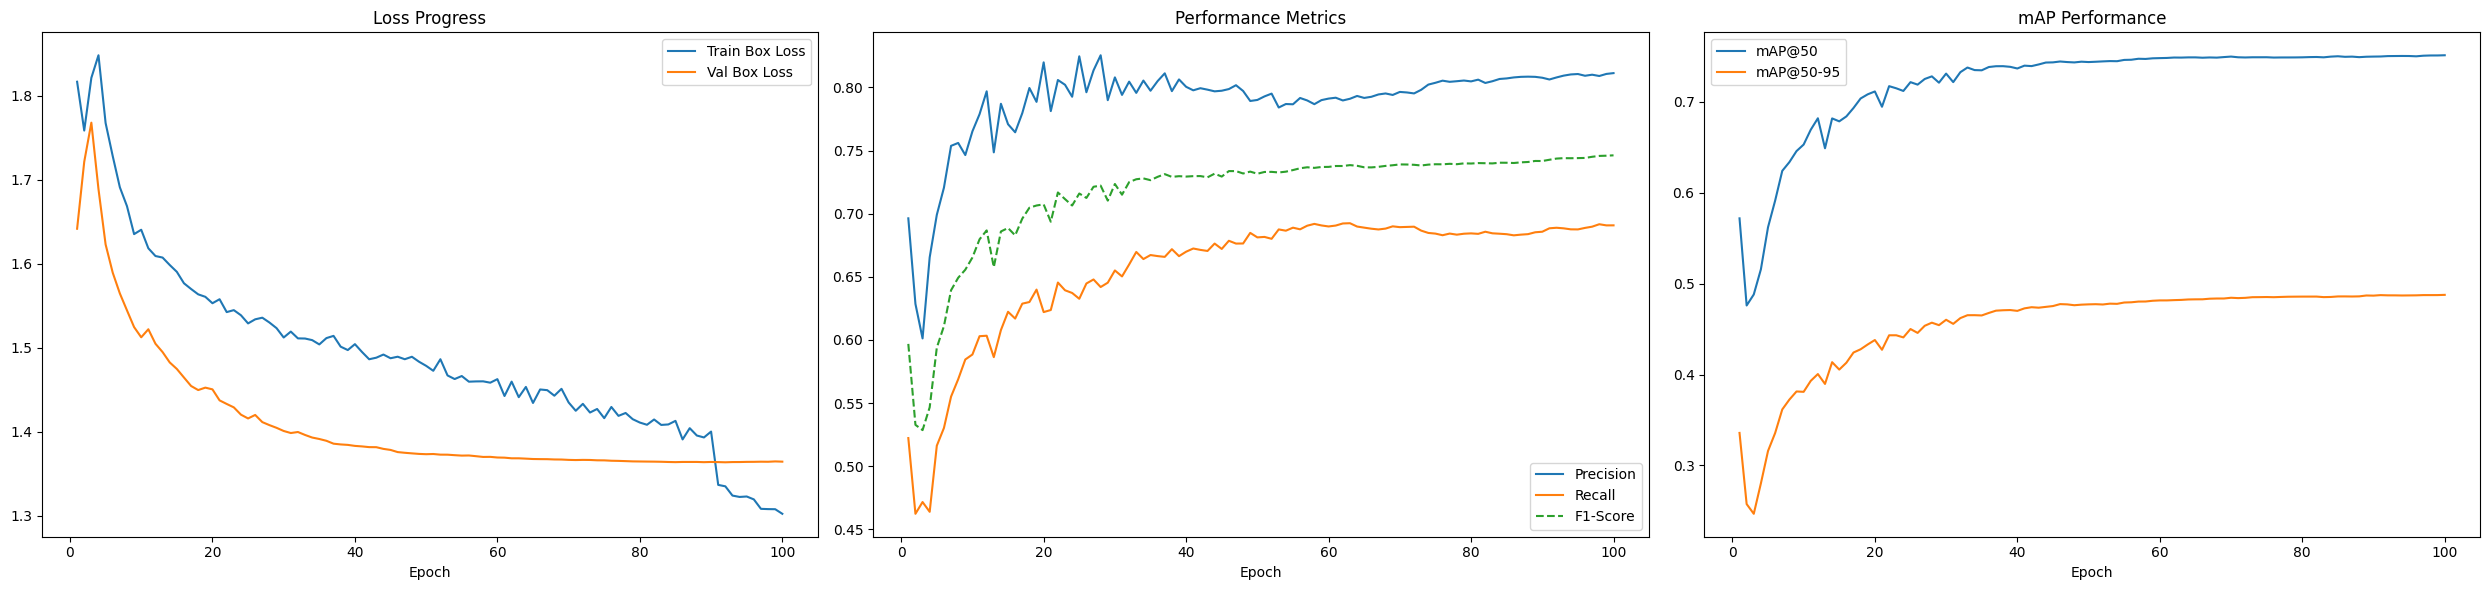

Grafik metrik berhasil disimpan sebagai 'training_metrics_horizontal.png'


In [3]:
from ultralytics import YOLO
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Model
model = YOLO('yolov8n.pt')

# 2. Train
results = model.train(
    data='Face_Person/data.yaml',
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,
    name='yolov8_mix_faceperson',
    project='Face_Person',
    pretrained=True,
    workers=4,
    amp=True,
    cache=False, 
    lr0 = 0.02,
    momentum=0.98,
    weight_decay=0.0001,
    hsv_v=0.6,
    mosaic=1.0,
    scale=0.5,
    translate=0.1
)

# 3. Custom Visualization & Plotting
# Ambil path folder hasil training secara dinamis dari objek 'results'
results_dir = results.save_dir
results_path = os.path.join(results_dir, 'results.csv')

print(f"Membaca hasil dari: {results_path}")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    df.columns = df.columns.str.strip()

    # Setup Plot Horizontal (A4 style landscape)
    fig, axs = plt.subplots(1, 3, figsize=(25, 6))

    # Plot 1: Loss Progress (Box Loss)
    axs[0].plot(df['epoch'], df['train/box_loss'], label='Train Box Loss')
    axs[0].plot(df['epoch'], df['val/box_loss'], label='Val Box Loss')
    axs[0].set_title('Loss Progress')
    axs[0].set_xlabel('Epoch')
    axs[0].legend()

    # Plot 2: Performance Metrics (Precision, Recall, F1)
    axs[1].plot(df['epoch'], df['metrics/precision(B)'], label='Precision')
    axs[1].plot(df['epoch'], df['metrics/recall(B)'], label='Recall')
    # Hitung F1-Score secara manual dari P dan R
    f1 = 2 * (df['metrics/precision(B)'] * df['metrics/recall(B)']) / (df['metrics/precision(B)'] + df['metrics/recall(B)'] + 1e-8)
    axs[1].plot(df['epoch'], f1, label='F1-Score', linestyle='--')
    axs[1].set_title('Performance Metrics')
    axs[1].set_xlabel('Epoch')
    axs[1].legend()

    # Plot 3: mAP50 & mAP50-95 (Combined)
    axs[2].plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP@50')
    axs[2].plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP@50-95')
    axs[2].set_title('mAP Performance')
    axs[2].set_xlabel('Epoch')
    axs[2].legend()

    plt.tight_layout()
    plt.savefig('training_metrics_horizontal.png')
    plt.show()
    print("Grafik metrik berhasil disimpan sebagai 'training_metrics_horizontal.png'")
else:
    print(f"Error: File {results_path} tidak ditemukan!")

In [4]:
# 1. Load best model dari hasil training
try:
    best_model_path = os.path.join(results.save_dir, 'weights', 'best.pt')
except NameError:
    best_model_path = 'Face_Person/yolov8_mix_faceperson/weights/best.pt'

best_model = YOLO(best_model_path)

# 2. Jalankan Val pada data TEST
stats = best_model.val(data='Face_Person/data.yaml', split='test')

# 3. Print Statistik Terperinci (All, Face, Person)
print("\n" + "="*45)
print(f"{'METRIC':<15} | {'ALL':<8} | {'FACE':<8} | {'PERSON':<8}")
print("-" * 45)

def calc_f1(p, r):
    return 2 * (p * r) / (p + r + 1e-8)

def get_val(var, idx):
    # Helper untuk menangani scalar vs array
    try:
        return var[idx]
    except (IndexError, TypeError):
        return var if idx == 0 else 0.0

# Metrik ALL (Rata-rata)
mAP50_all = stats.results_dict['metrics/mAP50(B)']
mAP95_all = stats.results_dict['metrics/mAP50-95(B)']
prec_all  = stats.results_dict['metrics/precision(B)']
rec_all   = stats.results_dict['metrics/recall(B)']
f1_all    = calc_f1(prec_all, rec_all)

# Metrik Per Class (Mengambil dari stats.box)
p_cls = stats.box.p
r_cls = stats.box.r
m50_cls = stats.box.map50
m95_cls = stats.box.map

# Ambil nilai per index dengan helper
p0, p1 = get_val(p_cls, 0), get_val(p_cls, 1)
r0, r1 = get_val(r_cls, 0), get_val(r_cls, 1)
m50_0, m50_1 = get_val(m50_cls, 0), get_val(m50_cls, 1)
m95_0, m95_1 = get_val(m95_cls, 0), get_val(m95_cls, 1)

# Print Row by Row
print(f"{'mAP@50':<15} | {mAP50_all:.4f} | {m50_0:.4f} | {m50_1:.4f}")
print(f"{'mAP@50-95':<15} | {mAP95_all:.4f} | {m95_0:.4f} | {m95_1:.4f}")
print(f"{'Precision':<15} | {prec_all:.4f} | {p0:.4f} | {p1:.4f}")
print(f"{'Recall':<15} | {rec_all:.4f} | {r0:.4f} | {r1:.4f}")
print(f"{'F1-Score':<15} | {f1_all:.4f} | {calc_f1(p0, r0):.4f} | {calc_f1(p1, r1):.4f}")

print("-" * 45)
print(f"Inference Speed : {stats.speed['inference']:.2f} ms per image")
print(f"Fitness         : {stats.fitness:.4f}")
print("="*45)

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1975.7±854.6 MB/s, size: 115.2 KB)
val: Scanning /kaggle/working/Face_Person/test/labels... 2257 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2257/2257 1.3Kit/s 1.8s
val: New cache created: /kaggle/working/Face_Person/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 142/142 8.0it/s 17.7s
                   all       2257      21127       0.82      0.706      0.768      0.509
                  face       1658      19849      0.909      0.533      0.661      0.356
                person        599       1278       0.73      0.879      0.875      0.662
Speed: 0.6ms preprocess, 3.3ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /kaggle/working/runs/detect/val

METRIC         